In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1.2

### a)

Ansatz: $I - T(h) = Ch^2$,   
$\quad I - T(h/2) = Ch^2/4$

Subtract: 
$T(h/2) - T(h) = \frac{3}{4}Ch^2 \;\Rightarrow\; C = \frac{4}{3}\,\frac{T(h/2)-T(h)}{h^2}$

$E(h) = Ch^2 = \frac{4}{3}\,\big(T(h/2) - T(h)\big)$

### b)

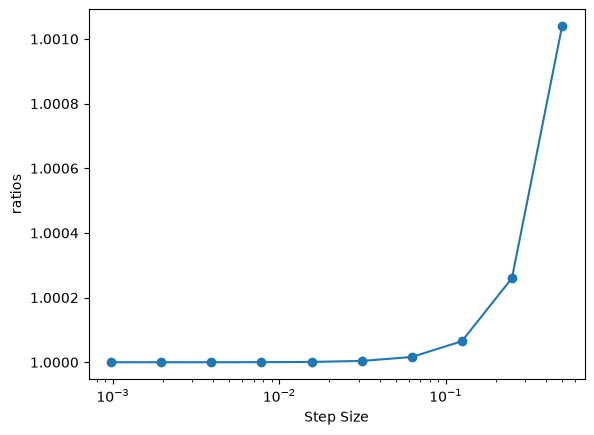

In [16]:
from typing import Callable, Final

import matplotlib

FUNCTION: Final[Callable[[float], float]] = \
        lambda x: np.exp(x)
N = np.array([2**(i + 1) for i in range(0, 10)])

def trapezoidal_rule(N: int,
        f: Callable[[float], float])-> float:
    h = 1 / N
    x_i = f(np.linspace(0, 1, N + 1))
    return np.sum(x_i[:-1] + x_i[1:]) * h / 2

err = lambda n, f: np.e - 1 - f(n, FUNCTION)
errors_trap = np.array([err(n, trapezoidal_rule)
                    for n in N])

def error_estimate():
    t_h = np.array([trapezoidal_rule(n, FUNCTION) for n in N])
    t_h_d2 = np.array([trapezoidal_rule(n, FUNCTION) for n in N * 2])
    return 4 / 3 * (t_h_d2 - t_h)

def compute_ratios(errors: np.ndarray, err_est: np.ndarray) -> np.ndarray:
    return errors / err_est

matplotlib.pyplot.semilogx(1 / N,
    compute_ratios(errors_trap, error_estimate()), 'o-')

matplotlib.pyplot.xlabel('Step Size')
matplotlib.pyplot.ylabel('ratios')

#It stops matplotlib from moving a common offset into the corner of the axis
plt.ticklabel_format(axis='y', useOffset=False)
matplotlib.pyplot.show()


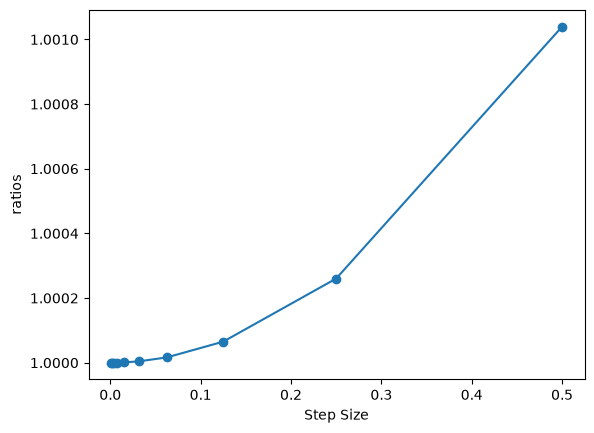

In [15]:
matplotlib.pyplot.plot(1 / N,
    compute_ratios(errors_trap, error_estimate()), 'o-')

matplotlib.pyplot.xlabel('Step Size')
matplotlib.pyplot.ylabel('ratios')

#It stops matplotlib from moving a common offset into the corner of the axis
plt.ticklabel_format(axis='y', useOffset=False)
matplotlib.pyplot.show()

### 1.2 b)
On the semilogx plot the estimated error approaches the real error for larger $N$ (smaller $h$):
$r \to 1$. Even for the largest step $h = 0.5$ the difference is only ≈ 0.001, i.e. 0.1%.

The deviation $r - 1$ grows like a parabola in $h$, which is visible on the second (linear) plot.